In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
import pandas as pd
city_day = pd.read_pickle('../data/processed/city_day_features.pkl')

In [6]:
city_day.head()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,City_Mumbai,City_Patna,City_Shillong,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam,Season_Monsoon,Season_Post-Monsoon,Season_Summer,Season_Winter
7398,2015-01-08,229.90,360.95,23.34,43.16,51.21,138.13,11.01,3.31,30.51,...,False,False,False,False,False,False,False,False,False,True
7399,2015-01-09,201.66,397.43,19.18,38.56,45.60,140.60,11.09,3.48,32.94,...,False,False,False,False,False,False,False,False,False,True
7400,2015-01-10,221.02,361.74,24.79,46.39,55.19,134.06,9.70,5.91,34.12,...,False,False,False,False,False,False,False,False,False,True
7401,2015-01-11,205.41,393.20,28.46,47.29,57.88,131.10,10.98,5.54,50.37,...,False,False,False,False,False,False,False,False,False,True
7402,2015-01-12,212.41,345.63,24.77,44.71,54.66,148.51,9.30,5.17,40.08,...,False,False,False,False,False,False,False,False,False,True


train test split 
not using sklearn train test split as there is features like previous day aqi which require previous rows 
and sklearn will randomly split it 
instead we want a continuous portion 


In [7]:
city_day = city_day.sort_values('Date')
split_date = city_day['Date'].quantile(0.8)  # or pick a specific date, e.g. cutoff at 2019-10-01

train = city_day[city_day['Date'] < split_date]
test = city_day[city_day['Date'] >= split_date]

print(train.shape, test.shape)

(16137, 45) (4044, 45)


In [8]:
train.columns

Index(['Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'AQI', 'AQI_Bucket', 'Month', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3',
       'AQI_lag7', 'AQI_roll3', 'AQI_roll7', 'DayOfWeek', 'Year',
       'City_Amaravati', 'City_Amritsar', 'City_Bengaluru', 'City_Bhopal',
       'City_Brajrajnagar', 'City_Chandigarh', 'City_Chennai',
       'City_Coimbatore', 'City_Delhi', 'City_Gurugram', 'City_Guwahati',
       'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai',
       'City_Patna', 'City_Shillong', 'City_Talcher',
       'City_Thiruvananthapuram', 'City_Visakhapatnam', 'Season_Monsoon',
       'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter'],
      dtype='str')

In [9]:
x_train = train.drop(columns=['AQI', 'Date', 'AQI_Bucket'])
y_train=train['AQI']

x_test = test.drop(columns=['AQI', 'Date', 'AQI_Bucket'])
y_test=test['AQI']

importing models 
and matrices

linear regression


In [14]:
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [22]:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

model_lr = LinearRegression()
model_lr.fit(x_train_scaled, y_train)

#coefficients_scaled = pd.Series(model_lr.coef_, index=x_train.columns).sort_values(key=abs, ascending=False)
#print(coefficients_scaled)
x_test_scaled = scaler.transform(x_test)
y_pred = model_lr.predict(x_test_scaled)

print("Linear Regression:")

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

Linear Regression:
Mean Squared Error: 372.8853945322147
R^2 Score: 0.9367612801313201
Mean Absolute Error: 12.447601475654512


random forest regression

In [23]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(x_train, y_train)

y_pred_rf = model_rf.predict(x_test)

print("Random Forest:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_rf))
print("R^2 Score:", r2_score(y_test, y_pred_rf))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_rf))

Random Forest:
Mean Squared Error: 277.7146488130564
R^2 Score: 0.9529015640267979
Mean Absolute Error: 10.595148367952522


xgboost regression


In [24]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model_xgb.fit(x_train, y_train)

y_pred_xgb = model_xgb.predict(x_test)

print("XGBoost:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))
print("R^2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))

XGBoost:
Mean Squared Error: 263.81188129865046
R^2 Score: 0.9552593748532205
Mean Absolute Error: 10.305494321677852


In [31]:
import os
print(os.getcwd())
print("==========")
print(os.listdir('..'))
print("==========")

print(os.listdir('.'))

d:\personal_project\aqi-predictor\notebook
['.git', 'data', 'models', 'notebook', 'requirement.txt']
['eda_and_cleaning.ipynb', 'model_building.ipynb']


In [33]:
import joblib

# Save the trained models
joblib.dump(model_lr, '../models/model_lr.pkl')
joblib.dump(model_rf, '../models/model_rf.pkl')
joblib.dump(model_xgb, '../models/model_xgb.pkl')
joblib.dump(scaler, '../models/scaler.pkl')


['../models/scaler.pkl']

In [34]:
columnlist = x_train.columns.tolist()
joblib.dump(columnlist, '../models/columnlist.pkl')

['../models/columnlist.pkl']

unsupervised learning 
clustering


In [35]:
cluster_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']


In [39]:
cluster_scaler=StandardScaler()
x_cluster = cluster_scaler.fit_transform(city_day[cluster_cols])

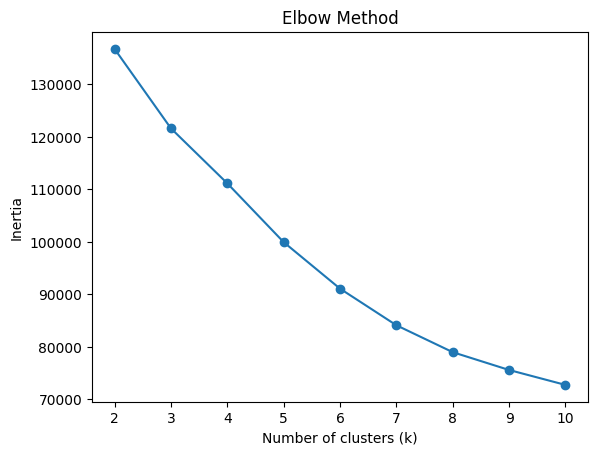

In [40]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_cluster)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

k=2, silhouette score=0.4216
k=3, silhouette score=0.2657
k=4, silhouette score=0.2802
k=5, silhouette score=0.2802
k=6, silhouette score=0.2678
k=7, silhouette score=0.1999
k=8, silhouette score=0.1984
k=9, silhouette score=0.1768
k=10, silhouette score=0.1753


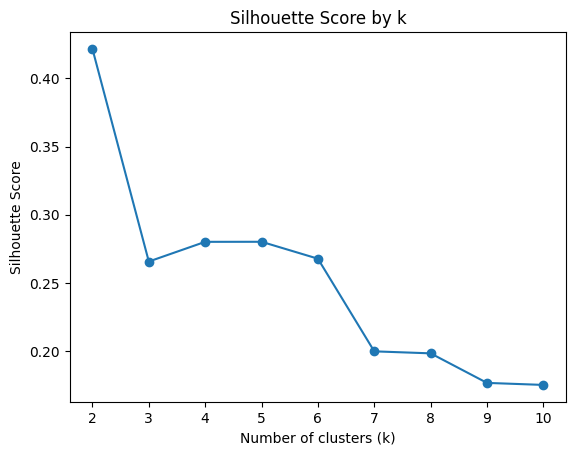

In [42]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.show()

In [43]:
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
city_day['pollution_cluster'] = kmeans_final.fit_predict(x_cluster)

print(city_day['pollution_cluster'].value_counts())

pollution_cluster
1    12181
3     5793
0     1501
2      706
Name: count, dtype: int64


In [44]:
print(city_day.groupby('pollution_cluster')['AQI'].mean().sort_values())

pollution_cluster
1     94.049996
2    122.813031
3    199.821163
0    326.276482
Name: AQI, dtype: float64


In [47]:
season_cols = [c for c in city_day.columns if 'Season_' in c]
print(city_day.groupby('pollution_cluster')[season_cols].mean())

                   Season_Monsoon  Season_Post-Monsoon  Season_Summer  \
pollution_cluster                                                       
0                        0.032645             0.283811       0.139241   
1                        0.428044             0.116493       0.301699   
2                        0.124646             0.260623       0.189802   
3                        0.156396             0.190402       0.285690   

                   Season_Winter  
pollution_cluster                 
0                       0.544304  
1                       0.153764  
2                       0.424929  
3                       0.367513  


In [48]:
cluster_labels = {1: 'Good', 2: 'Moderate', 3: 'Poor', 0: 'Severe'}
city_day['pollution_level'] = city_day['pollution_cluster'].map(cluster_labels)

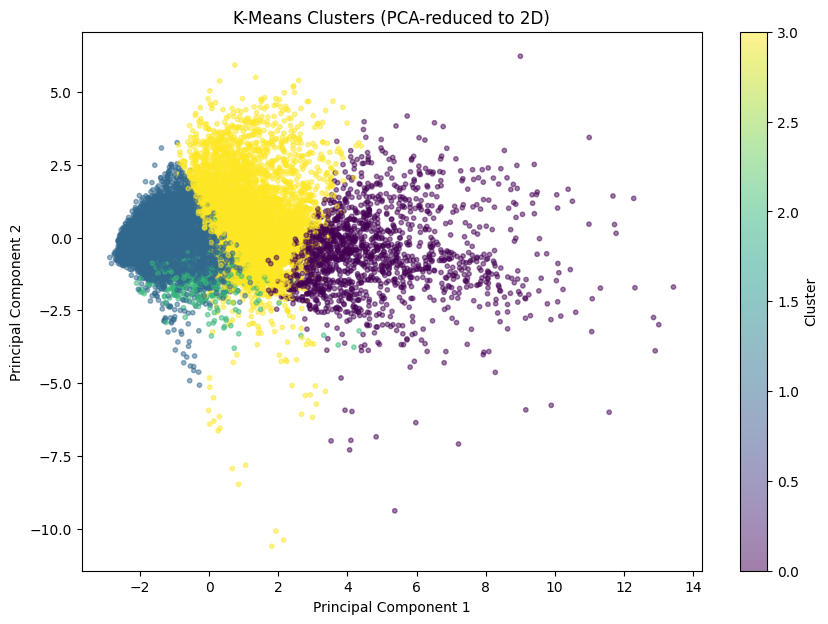

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_cluster)  # using your already-scaled cluster data

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=city_day['pollution_cluster'], cmap='viridis', alpha=0.5, s=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (PCA-reduced to 2D)')
plt.colorbar(scatter, label='Cluster')
plt.show()

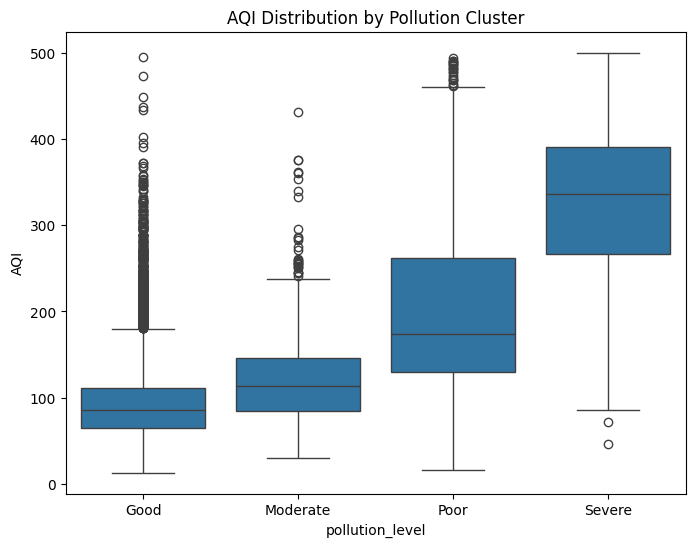

In [50]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='pollution_level', y='AQI', data=city_day, order=['Good', 'Moderate', 'Poor', 'Severe'])
plt.title('AQI Distribution by Pollution Cluster')
plt.show()

In [54]:
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')

['../models/kmeans_model.pkl']

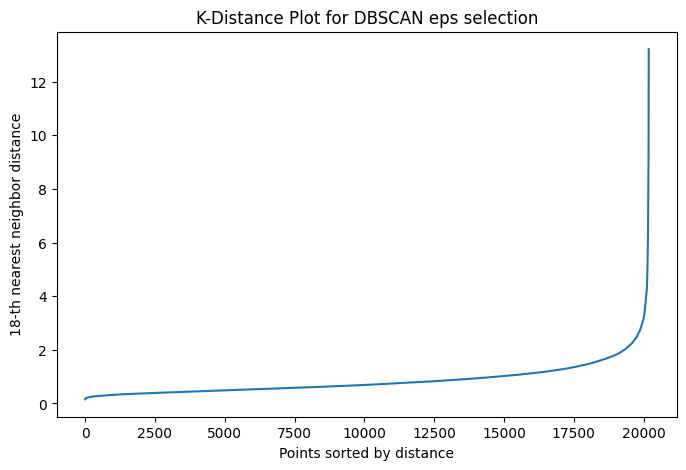

In [51]:
min_samples=2*len(cluster_cols)
from sklearn.neighbors import NearestNeighbors

k = min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x_cluster)
distances, indices = neighbors_fit.kneighbors(x_cluster)

# Sort distances to the k-th neighbor
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-th nearest neighbor distance')
plt.title('K-Distance Plot for DBSCAN eps selection')
plt.show()

In [53]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=min_samples)
city_day['dbscan_cluster'] = dbscan.fit_predict(x_cluster)

print(city_day['dbscan_cluster'].value_counts())

dbscan_cluster
 0    19800
-1      381
Name: count, dtype: int64
